# Zomato Data Analysis Project
## Objective
This project analyzes Zomato restaurant and food item data to understand ratings, prices, cuisines, votes, and city-wise trends.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df= pd.read_csv('zomato_dataset.csv')
df.head(10)

,Restaurant Name,Dining Rating,Delivery Rating,Dining Votes,Delivery Votes,Cuisine,Place Name,City,Item Name,Best Seller,Votes,Prices
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NaN,39,189.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0
5,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Pizza [8 inches],BESTSELLER,48,199.0
6,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Zinger Tortilla Wrap,CHEF'S SPECIAL,27,165.0
7,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Popcorn [20 Pieces],BESTSELLER,59,165.0
8,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Sandwich,NaN,29,115.0
9,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Bread Samoli Shawarma,NaN,31,129.0


## Basic Information About Dataset
We will check the size of the dataset, column names, data types, and missing values.

In [16]:
print("Shape of the dataset:")
print(df.shape)
print("\nColumns in the dataset:")
print(df.columns)
print("\nDataset information:")
print(df.info())

Shape of the dataset:
(123657, 12)

Columns in the dataset:
Index(['Restaurant Name', 'Dining Rating', 'Delivery Rating', 'Dining Votes',
       'Delivery Votes', 'Cuisine ', 'Place Name', 'City', 'Item Name',
       'Best Seller', 'Votes', 'Prices'],
      dtype='str')

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 123657 entries, 0 to 123656
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Restaurant Name  123657 non-null  str    
 1   Dining Rating    91421 non-null   float64
 2   Delivery Rating  122377 non-null  float64
 3   Dining Votes     123657 non-null  int64  
 4   Delivery Votes   123657 non-null  int64  
 5   Cuisine          123657 non-null  str    
 6   Place Name       123657 non-null  str    
 7   City             123657 non-null  str    
 8   Item Name        123657 non-null  str    
 9   Best Seller      27942 non-null   str    
 10  Votes            123657 non-null  int6

In [17]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Restaurant Name        0
Dining Rating      32236
Delivery Rating     1280
Dining Votes           0
Delivery Votes         0
Cuisine                0
Place Name             0
City                   0
Item Name              0
Best Seller        95715
Votes                  0
Prices                 0
dtype: int64


In [18]:
print("Duplicate rows in the dataset:")
print(df.duplicated().sum())

Duplicate rows in the dataset:
22127


## Data Cleaning
In this section, we will:
- remove duplicates
- handle missing values
- clean important columns if needed

In [19]:
df.columns= df.columns.str.strip()
print(df.columns)

Index(['Restaurant Name', 'Dining Rating', 'Delivery Rating', 'Dining Votes',
       'Delivery Votes', 'Cuisine', 'Place Name', 'City', 'Item Name',
       'Best Seller', 'Votes', 'Prices'],
      dtype='str')


# Exploratory Data Analysis
In this section, we will analyze:
- Top cities with most food items
- Most common cuisines
- Average prices
- Best seller items
- Ratings distribution
- Votes analysis

In [20]:
df.head()

,Restaurant Name,Dining Rating,Delivery Rating,Dining Votes,Delivery Votes,Cuisine,Place Name,City,Item Name,Best Seller,Votes,Prices
0,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Platter Kebab Combo,BESTSELLER,84,249.0
1,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Rumali Shawarma,BESTSELLER,45,129.0
2,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken Tandoori Salad,NaN,39,189.0
3,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Chicken BBQ Salad,BESTSELLER,43,189.0
4,Doner King,3.9,4.2,39,0,Fast Food,Malakpet,Hyderabad,Special Doner Wrap Combo,MUST TRY,31,205.0


In [21]:
print(df[['Restaurant Name', 'City', 'Cuisine', 'Item Name', 'Prices']].head())

  Restaurant Name        City    Cuisine                 Item Name  Prices
0      Doner King   Hyderabad  Fast Food       Platter Kebab Combo   249.0
1      Doner King   Hyderabad  Fast Food   Chicken Rumali Shawarma   129.0
2      Doner King   Hyderabad  Fast Food    Chicken Tandoori Salad   189.0
3      Doner King   Hyderabad  Fast Food         Chicken BBQ Salad   189.0
4      Doner King   Hyderabad  Fast Food  Special Doner Wrap Combo   205.0


## Top 10 Cities with Most Food Items

In [22]:
top_cities= df['City'].value_counts().head(10)
print(top_cities)

City
Hyderabad    15613
Jaipur       14438
Mumbai       13535
Chennai      13100
Bangalore    12040
Ahmedabad    10178
Kolkata       8662
Pune          8067
Kochi         7759
Raipur        7700
Name: count, dtype: int64


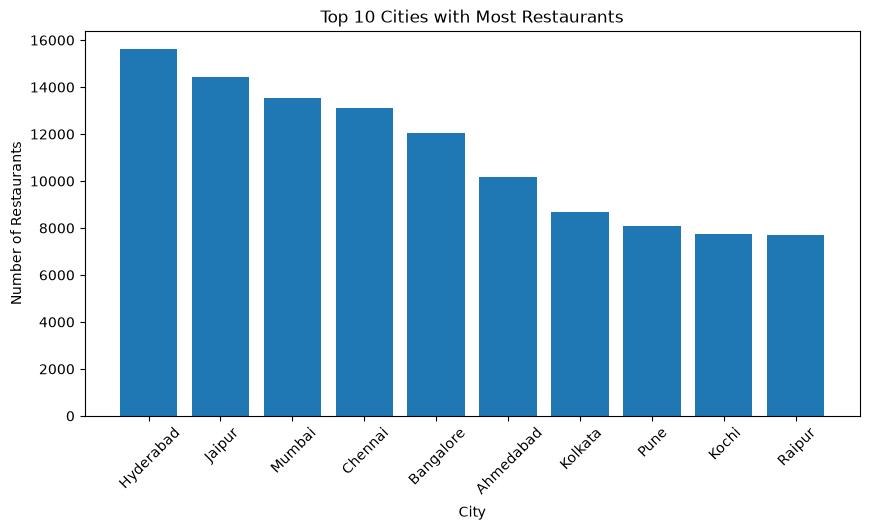

In [23]:
plt.figure(figsize=(10,5))
plt.bar(top_cities.index, top_cities.values)
plt.xlabel('City')
plt.ylabel('Number of Restaurants')
plt.title('Top 10 Cities with Most Restaurants')
plt.xticks(rotation=45)
plt.show()

## Price Analysis

In [24]:
print("Maximum price:", df['Prices'].max())
print("Minimum price:", df['Prices'].min())
print("Average price:", df['Prices'].mean())

Maximum price: 12024.0
Minimum price: 0.95
Average price: 241.3783985540649


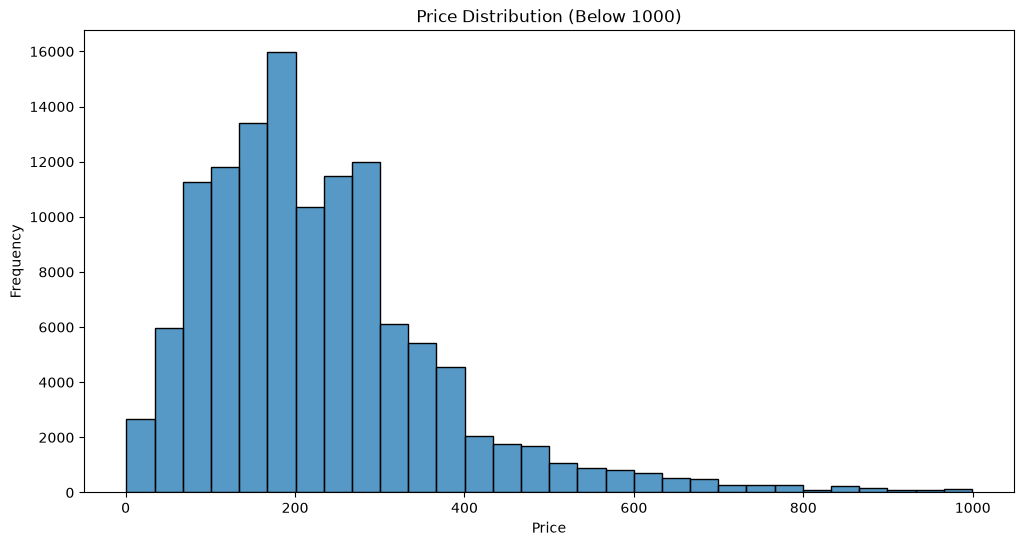

In [25]:
plt.figure(figsize=(12,6))
sns.histplot(df['Prices'][df['Prices'] < 1000], bins=30)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution (Below 1000)')
plt.show()